In [1]:
import shutil
import random
import hashlib
import zipfile
import requests
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

**Pathing**

In [2]:
# Upward search for project directory root

start_dir = (Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve())

root_dir = next( (path for path in (start_dir, *start_dir.parents) if (path / "environment.yml").is_file() and (path / "notebooks").is_dir()), None )

if root_dir is None:

    raise FileNotFoundError(

        f"Could not locate project root from {start_dir}"

    )

In [3]:
archive_path = root_dir / "data" / "EuroSAT.zip"  # Path("../data/EuroSAT.zip")
archive_path.parent.mkdir(parents=True, exist_ok=True)

raw_dir = root_dir / "data" / "raw"  # Path("../data/raw")  # `extract_dir`
raw_dir.mkdir(parents=True, exist_ok=True)

dataset_dir = raw_dir / "eurosat"  # pre-alloc.

**Data Download**

In [4]:
# Source (Official EuroSAT archive)
dl_url = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1"  # https://madm.dfki.de/files/sentinel/EuroSAT.zip (deprecated)

# Note: Zenodo checksum --> `md5:f46e308c4d50d4bf32fedad2d3d62f3b` (`https://zenodo.org/records/7711810`)
expected_checksum = "f46e308c4d50d4bf32fedad2d3d62f3b"

# Download dataset
if not dataset_dir.exists() and not archive_path.exists():

    print("Downloading EuroSAT dataset...")

    partial_file = archive_path.with_suffix(".zip.part")

    if partial_file.exists():

        partial_file.unlink()

    # response = requests.get(dl_url, stream=True)
    with requests.get(dl_url, stream=True, timeout=(10, 60)) as response:

        response.raise_for_status()

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024  # 1 KiB
        
        with open(partial_file, 'wb') as file, tqdm(

            desc="EuroSAT.zip",
            total=total_size,
            unit='iB',
            unit_scale=True,
            unit_divisor=1024,

        ) as bar:

            for chunk in response.iter_content(block_size):

                file.write(chunk)
                bar.update(len(chunk))

    # Validate dataset
    print("Validating downloaded ZIP archive...")

    try:

        # Validate MD5 checksum
        print("Validating MD5 checksum...")
        checksum = hashlib.md5()

        with open(partial_file, "rb") as f:

            # 
            for chunk in iter(lambda: f.read(8192), b""):

                checksum.update(chunk)

        if checksum.hexdigest() != expected_checksum:

            raise ValueError(

                f"Checksum mismatch! Expected: {expected_checksum}. Got: {checksum.hexdigest()}"

            )

        with zipfile.ZipFile(partial_file, 'r') as z:

            bad_file = z.testzip()

            if bad_file is not None:

                raise zipfile.BadZipFile(f"Corrupted archive: {bad_file}")

    except Exception as e:

        if partial_file.exists():

            partial_file.unlink()

        raise RuntimeError(f"Downloaded archive is invalid or corrupted: {e}")


    # Rename to final target
    partial_file.rename(archive_path)
    print("[✓] EuroSAT data downloaded and verified successfully.")



EuroSAT.zip: 100%|██████████| 90.3M/90.3M [00:08<00:00, 11.1MiB/s]


Validating downloaded ZIP archive...
Validating MD5 checksum...
[✓] EuroSAT data downloaded and verified successfully.


**Data Extraction**

In [5]:
# Extract `.zip` archive

extract_dir_tmp = raw_dir / "eurosat_tmp"  # temporary

if not dataset_dir.exists():

    print("Extracting EuroSAT dataset...")

    # Clean-up potential previous (failed) runs
    if extract_dir_tmp.exists():

        shutil.rmtree(extract_dir_tmp)

    extract_dir_tmp.mkdir(parents=True, exist_ok=True)

    try:

        with zipfile.ZipFile(archive_path, 'r') as z:

            img_dirs = [

                Path(name)
                for name in z.namelist()
                if name.lower().endswith(('.jpg', '.jpeg', '.png'))
                and not any(

                        part.startswith('.') or (part == '__MACOSX') 
                        for part in Path(name).parts
                        
                    )

            ]

            if not img_dirs:

                raise ValueError("Expected image data not found in present archive.")

            # Extract to temp. dir
            z.extractall(extract_dir_tmp)

            # Check if image data stored in single top-level wrapper dir
            top_levels = {p.parts[0] for p in img_dirs}

            # e.g. "EuroSAT_RGB"
            if len(top_levels) == 1:

                # Wrapper folder
                wrapper_folder = top_levels.pop()
                source_dir = extract_dir_tmp / wrapper_folder
                source_dir.rename(dataset_dir)  # Move to target via `.rename()`

            else:

                # No wrapper
                extract_dir_tmp.rename(dataset_dir)

    finally:

        if extract_dir_tmp.exists():

            shutil.rmtree(extract_dir_tmp)

    # Remove EuroSAT data archive
    archive_path.unlink()  # via `pathlib.Path.unlink()`

print("[✓] EuroSAT data archive extracted successfully.")

Extracting EuroSAT dataset...
[✓] EuroSAT data archive extracted successfully.


****Dataset Diagnostics****

In [6]:
# Class names: labels

print("All Classes (Labels) in EuroSAT dataset:\n")

class_ids = []

for idx, path in enumerate(dataset_dir.iterdir()):

    print(idx, path)

    if path.is_dir():

        class_ids.append(path.name)

class_ids = sorted(class_ids)
c_total = len(class_ids)

print(f"\n Total of {c_total} different classes: {class_ids}")

All Classes (Labels) in EuroSAT dataset:

0 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/SeaLake
1 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/Highway
2 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/HerbaceousVegetation
3 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/PermanentCrop
4 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/Pasture
5 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/Forest
6 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/Industrial
7 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/AnnualCrop
8 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/Residential
9 /home/jlx/dev/projects/satellite-image-classification/data/raw/eurosat/River

 Total of 10 different classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'Per

In [7]:
print("Running dataset eval...")

class_counts = {}
corrupt_images = []

sizes = set()
modes = set()

for class_id in tqdm(class_ids, desc="Scanning respective classes"):

    class_dir = dataset_dir / class_id
    images = list(class_dir.glob("*.jpg"))
    class_counts[class_id] = len(images)

    for image in images:

        try:

            # Data validity check
            with Image.open(image) as img:

                # Read metadata
                sizes.add(img.size)
                modes.add(img.mode)

                img.verify()  # `.verify()` reads file headers and structure

        except Exception as e:

            corrupt_images.append((image, str(e)))

total_images = sum(class_counts.values())

if corrupt_images:

    print("\n[WARNING] Corrupt images detected:")

    for path, err in corrupt_images[:5]:

        print(f"  - {path.name}: {err}")

else:

    print("[✓] All images verified successfully!")

print("\n--- Eval Summary ---")
print(f"Total image count: {total_images}")
print(f"Unique image dimensions: {sizes}")
print(f"Unique color modes: {modes}")
print(f"Corrupt images: {len(corrupt_images)}")

Running dataset eval...


Scanning respective classes: 100%|██████████| 10/10 [00:00<00:00, 12.04it/s]

[✓] All images verified successfully!

--- Eval Summary ---
Total image count: 27000
Unique image dimensions: {(64, 64)}
Unique color modes: {'RGB'}
Corrupt images: 0


In [8]:
# Class distribution
class_count_list = list(class_counts.items()) 
df = pd.DataFrame(class_count_list, columns=['Class', 'numel']).sort_values('Class')
df

,Class,numel
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


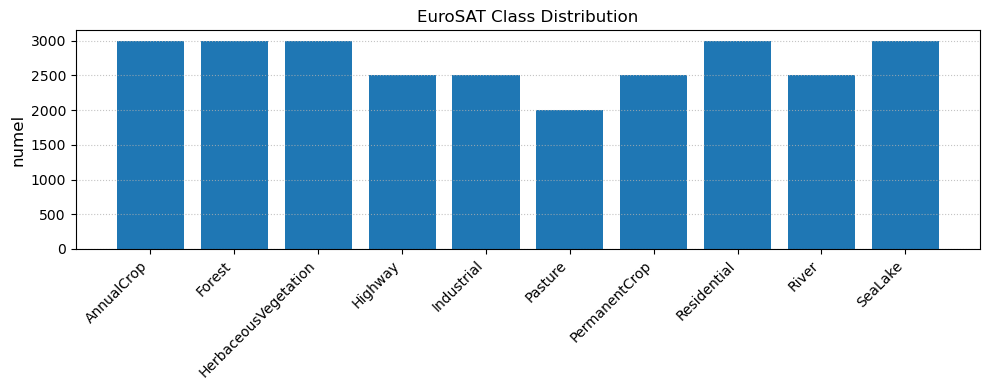

In [9]:
plt.figure(figsize=(10, 4))

classes_sorted = sorted(class_counts.keys())
counts_sorted = [class_counts[c] for c in classes_sorted]

plt.bar(classes_sorted, counts_sorted)

# plt.xlabel('Class Label', fontsize=12)
plt.ylabel('numel', fontsize=12)
plt.title('EuroSAT Class Distribution')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.75)

plt.tight_layout()
plt.show()

**Data Organization** (note: deprecated TensorFlow approach)

In [10]:
# # Total dataset size (number of examples/images)

# split_keys = list(info.splits.keys())
# split_key= split_keys[0]
# ds_size = info.splits[split_key].num_examples

# # Store images in class-specific subdirectories
# with tqdm(total=ds_size, desc="Processing images", unit="img") as pbar:

#     for idx, (image, label) in enumerate(ds[split_key]):

#         image_np = image.numpy()
#         label_np = label.numpy()

#         class_id = class_ids[label_np]

#         class_dir = archive_path / class_id
#         class_dir.mkdir(exist_ok=True)

#         image_pil = Image.fromarray(image_np)

#         # Save
#         image_id = f"{idx:05d}"
#         image_pil.save(class_dir / f"{image_id}.jpg")

#         pbar.update(1)

#     print(f"All {ds_size} images processed and saved to {archive_path}.")

**Data Samples**

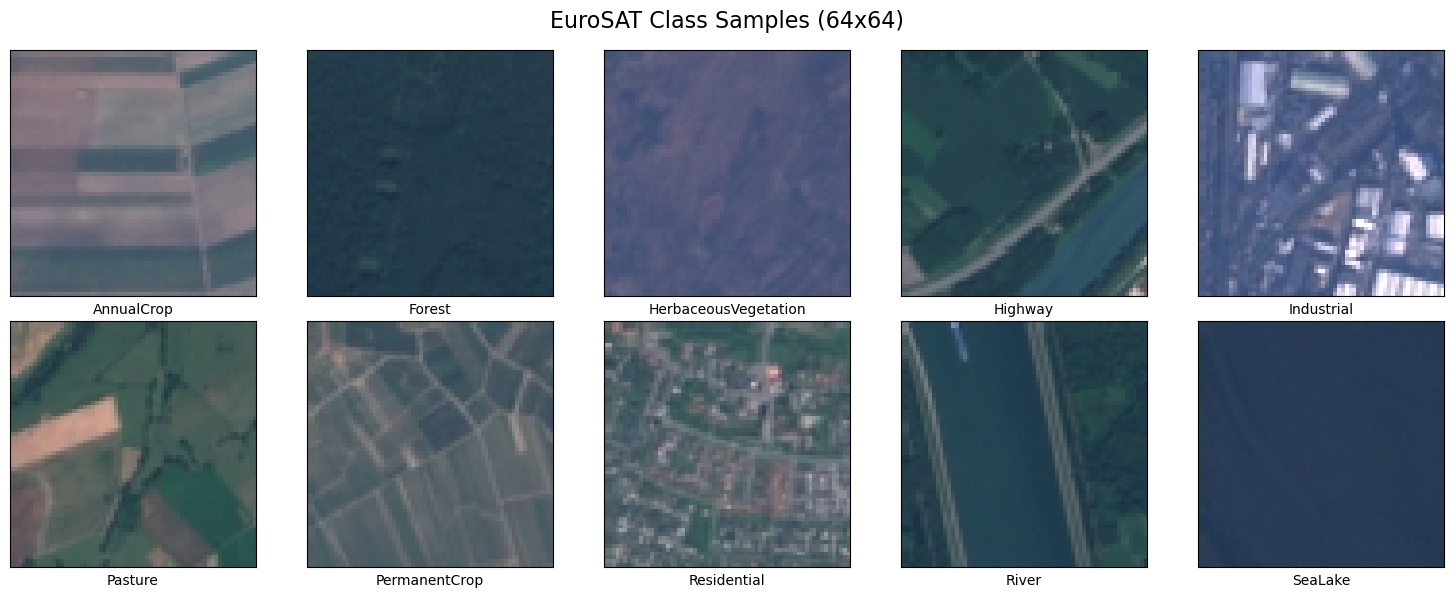

In [11]:
rng = random.Random(42)  # Reproducible samples

n_classes = len(class_ids)

cols = 5
rows = ( n_classes + cols - 1 ) // cols  # Rows via floor division 

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), squeeze=False)  # `squeeze=False` --> `axes` object always 2D (rows, cols) array
fig.suptitle('EuroSAT Class Samples (64x64)', fontsize=16)

axes_flat = axes.flatten()  # collapse into flat 1D array (`[ax1, ax2, ...]`)

for idx, class_id in enumerate(class_ids):

    # row = idx // cols
    # col = idx % cols
    # ax = axes[row, col]

    ax = axes_flat[idx]  # simplify via "flatten" logic
    
    class_dir = dataset_dir / class_id

    sample_dir = rng.choice(list(class_dir.glob("*.jpg")))

    with Image.open(sample_dir) as sample:

        ax.imshow(sample)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(class_id)

# Hide unused subplots
for idx in range(n_classes, len(axes_flat)):
    
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()